# OpenPlaque — Cross-Rotation Consensus Coronary Tracking

This notebook uses a property specific to the Siemens curved coronary reformat stack: each frame is an alternate rotation around the same vessel. The target coronary should remain relatively stable in CPR pixel coordinates while chambers, bones, and other anatomy move with rotation.

The workflow therefore builds **persistent coronary evidence across every rotation first**, tracks on that consensus image, and only then selects the individual CPR rotation that displays the fixed path best. Plaque is **not used to generate or choose the path**; it is overlaid afterward for visualization.

Every persistent component has a Boolean reuse flag. All default to `True`: valid cache → reuse; missing/invalid cache → recompute and cache; `False` → force recomputation and replace the cache. Canonical TPV is unchanged. CPR plaque views and source-volume PCAT are not spatially co-registered. Research use only.


## Step 1 — Mount Google Drive

In [1]:
# FIRST EXECUTABLE CELL — Drive mount must remain first.
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Step 2 — Cache / reuse controls

In [2]:
# Default behavior: reuse every valid cache.
REUSE_SERIES_SELECTION = True
REUSE_PLAQUE_MASKS = True
REUSE_CONSENSUS_EVIDENCE = True
REUSE_TRACKING = True
REUSE_CANDIDATE_FIGURE = True
REUSE_ROADMAPS = True
REUSE_PCAT_FIGURES = True
REUSE_DASHBOARD = True
REUSE_REPORT_PACKAGE = True


## Step 3 — Install this fresh branch

In [3]:
!rm -rf /content/OpenPlaque
!git clone -q --branch cross-rotation-consensus-tracking-from-main --single-branch https://github.com/pazzani/OpenPlaque.git /content/OpenPlaque
!pip -q install -r /content/OpenPlaque/requirements-colab.txt

import sys
sys.path.insert(0, '/content/OpenPlaque/src')
import pandas as pd
from IPython.display import display, Image
from openplaque.consensus_tracking_workflow import ConsensusTrackingWorkflow

print('Cross-rotation consensus tracker ready.')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.9/18.9 MB 45.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.1/291.1 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.2/248

## Step 4 — Initialize and inspect the cache plan

The table shows which persistent components are currently available and whether this run plans to reuse or recompute them.


In [4]:
REUSE = {
    'series_selection': REUSE_SERIES_SELECTION,
    'plaque_masks': REUSE_PLAQUE_MASKS,
    'consensus_evidence': REUSE_CONSENSUS_EVIDENCE,
    'tracking': REUSE_TRACKING,
    'candidate_figure': REUSE_CANDIDATE_FIGURE,
    'roadmaps': REUSE_ROADMAPS,
    'pcat_figures': REUSE_PCAT_FIGURES,
    'dashboard': REUSE_DASHBOARD,
    'report_package': REUSE_REPORT_PACKAGE,
}
wf = ConsensusTrackingWorkflow('/content/drive/MyDrive/OpenPlaque', REUSE)
display(wf.cache_status())


,component,reuse,cache_available,planned_action,cache_path
0,series_selection,True,False,recompute_and_cache,/content/drive/MyDrive/OpenPlaque/Cache/Cross_...
1,plaque_masks,True,True,reuse,/content/drive/MyDrive/OpenPlaque/Cache/Cross_...
2,consensus_evidence,True,False,recompute_and_cache,/content/drive/MyDrive/OpenPlaque/Cache/Cross_...
3,tracking,True,False,recompute_and_cache,/content/drive/MyDrive/OpenPlaque/Cache/Cross_...
4,candidate_figure,True,False,recompute_and_cache,/content/drive/MyDrive/OpenPlaque/Cache/Cross_...
5,roadmaps,True,False,recompute_and_cache,/content/drive/MyDrive/OpenPlaque/Cache/Cross_...
6,pcat_figures,True,False,recompute_and_cache,/content/drive/MyDrive/OpenPlaque/Cache/Cross_...
7,dashboard,True,False,recompute_and_cache,/content/drive/MyDrive/OpenPlaque/Cache/Cross_...
8,report_package,True,False,recompute_and_cache,/content/drive/MyDrive/OpenPlaque/Cache/Cross_...


## Step 5 — Prepare DICOM and coronary CPR series

In [5]:
series_map = wf.prepare_inputs()
print('Series:', series_map)


Series: {'LAD': 1043, 'RCA': 1035, 'LCX': 1039}


## Step 6 — Load canonical plaque masks

Existing validated plaque masks are reused if geometry and canonical TPV agree. nnU-Net runs only on a genuine cache miss or when `REUSE_PLAQUE_MASKS=False`. These masks are **not** used to generate the consensus path.


In [6]:
cache_qc = wf.load_plaque_masks()
display(cache_qc)


,vessel,source,path,expected_tpv_mm3,plaque_voxels
0,LAD,cache,/content/drive/MyDrive/OpenPlaque/Cache/Cross_...,538.0,538
1,RCA,cache,/content/drive/MyDrive/OpenPlaque/Cache/Cross_...,1037.0,1037
2,LCX,cache,/content/drive/MyDrive/OpenPlaque/Cache/Cross_...,90.0,90


## Step 7 — Build cross-rotation consensus evidence

For every CPR rotation, the code computes coronary-scale vesselness/local-contrast evidence. It then combines the lower quartile, median, upper quantile, and persistence fraction across rotations. Structures that are bright in only a few rotations are suppressed.


In [7]:
consensus = wf.build_consensus_evidence()
for vessel in ('LAD','RCA','LCX'):
    c = consensus[vessel]['consensus']
    s = consensus[vessel]['support']
    print(vessel, 'consensus max=', float(c.max()), 'mean support=', float(s[c>0].mean()) if (c>0).any() else 0)


LAD consensus max= 0.9998642802238464 mean support= 0.03881814330816269
RCA consensus max= 0.9999966621398926 mean support= 0.03232254460453987
LCX consensus max= 0.9998245239257812 mean support= 0.03712490200996399


## Step 8 — Track the persistent coronary path and choose the best rotation

Tracking is performed on the consensus image, not independently on each rotation. The selected path is fixed first; the best individual rotation is chosen afterward using lumen HU plausibility and local path-versus-background contrast. Plaque does not participate in either decision.


In [8]:
tracking_qc = wf.track_consensus_paths()
display(tracking_qc)


,vessel,selected_frame,path_length_mm,endpoint_distance_mm,sinuosity,mean_consensus,mean_cross_rotation_support,mean_path_hu,plausible_hu_fraction,core_minus_ring_hu,plaque_voxels_in_selected_frame,plaque_voxels_within_5mm_tube,plaque_capture_pct_of_selected_frame,tracking_status,qc_reason
0,LAD,17,173.982756,151.795916,1.146162,0.807231,0.246572,443.491667,0.759494,171.904712,0,0,0.0,REVIEW,modest cross-rotation persistence
1,RCA,16,20.656854,17.464249,1.182808,0.601725,0.072917,324.526316,0.950000,144.463514,0,0,0.0,FAIL,low cross-rotation persistence
2,LCX,12,32.899495,28.861739,1.139900,0.787520,0.098118,551.838710,1.000000,128.965668,22,0,0.0,FAIL,low cross-rotation persistence; selected-frame...


## Step 9 — Review consensus candidates

Each row shows the top three persistent paths for one artery on the same cross-rotation consensus image. The first column is the actual selected path.


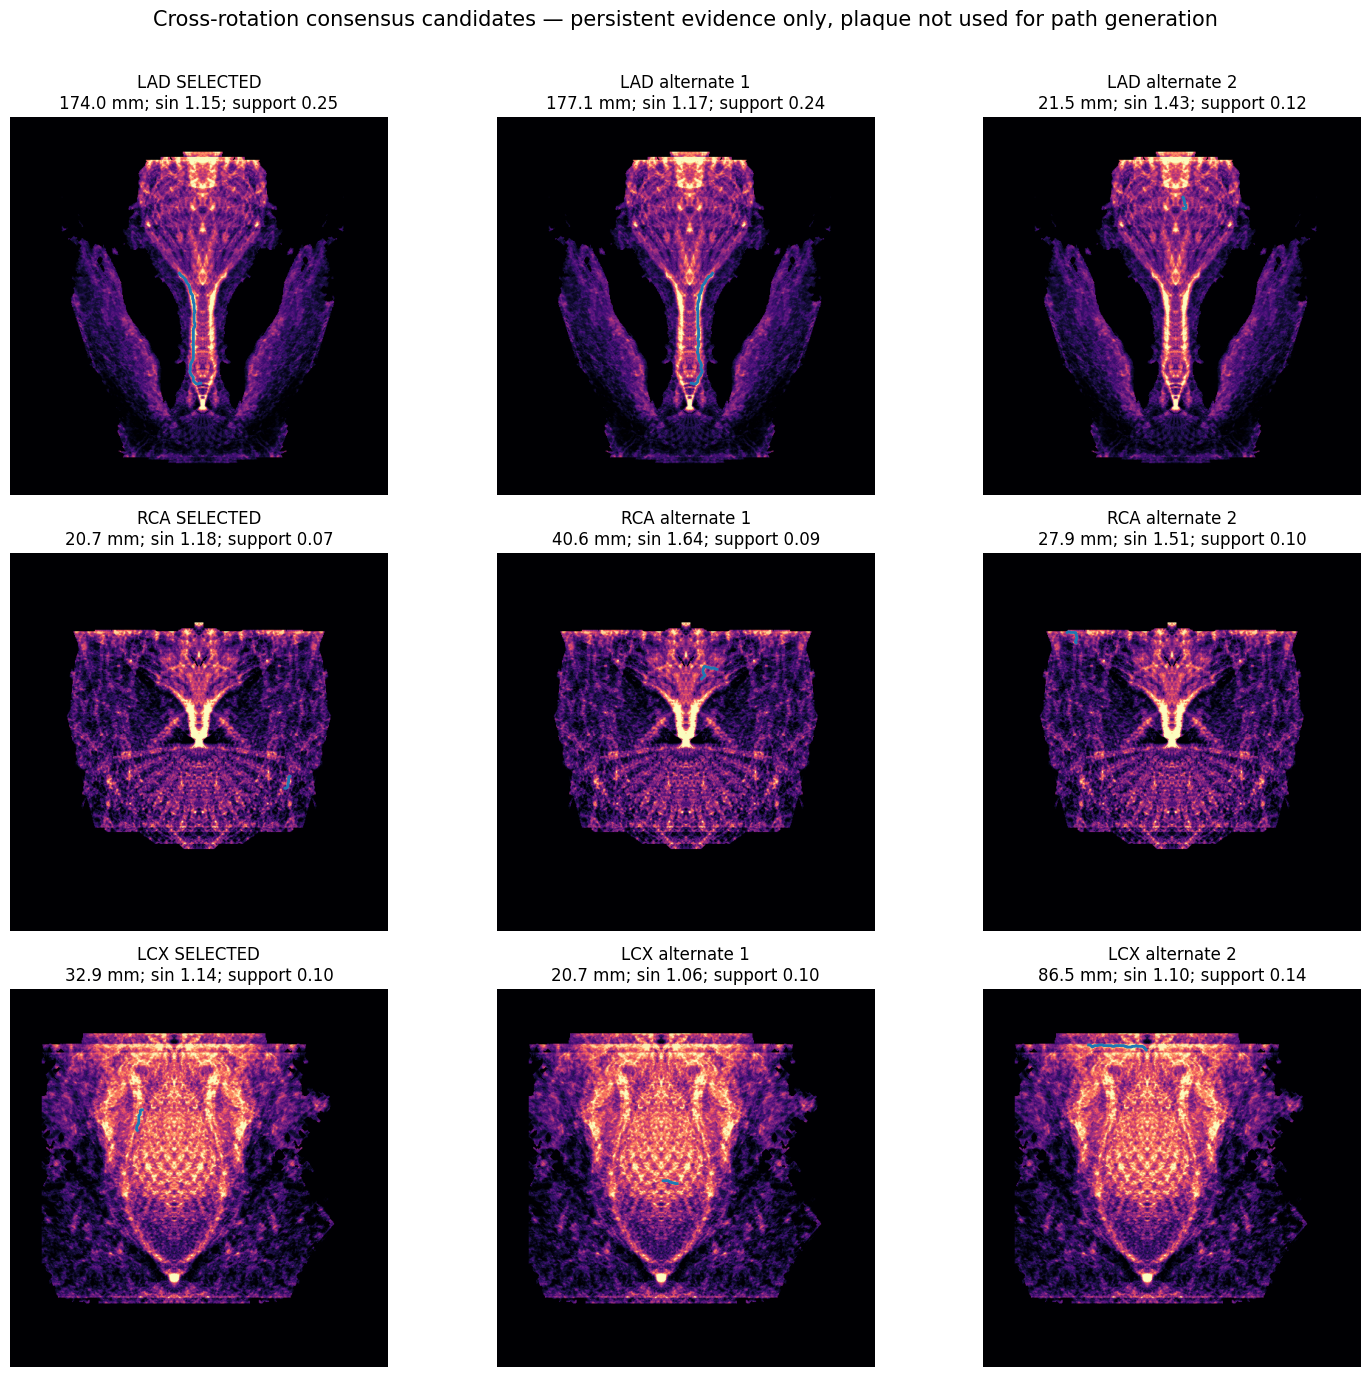

Saved: /content/drive/MyDrive/OpenPlaque/Cross_Rotation_Consensus_Tracking_Report/01_consensus_candidates.png


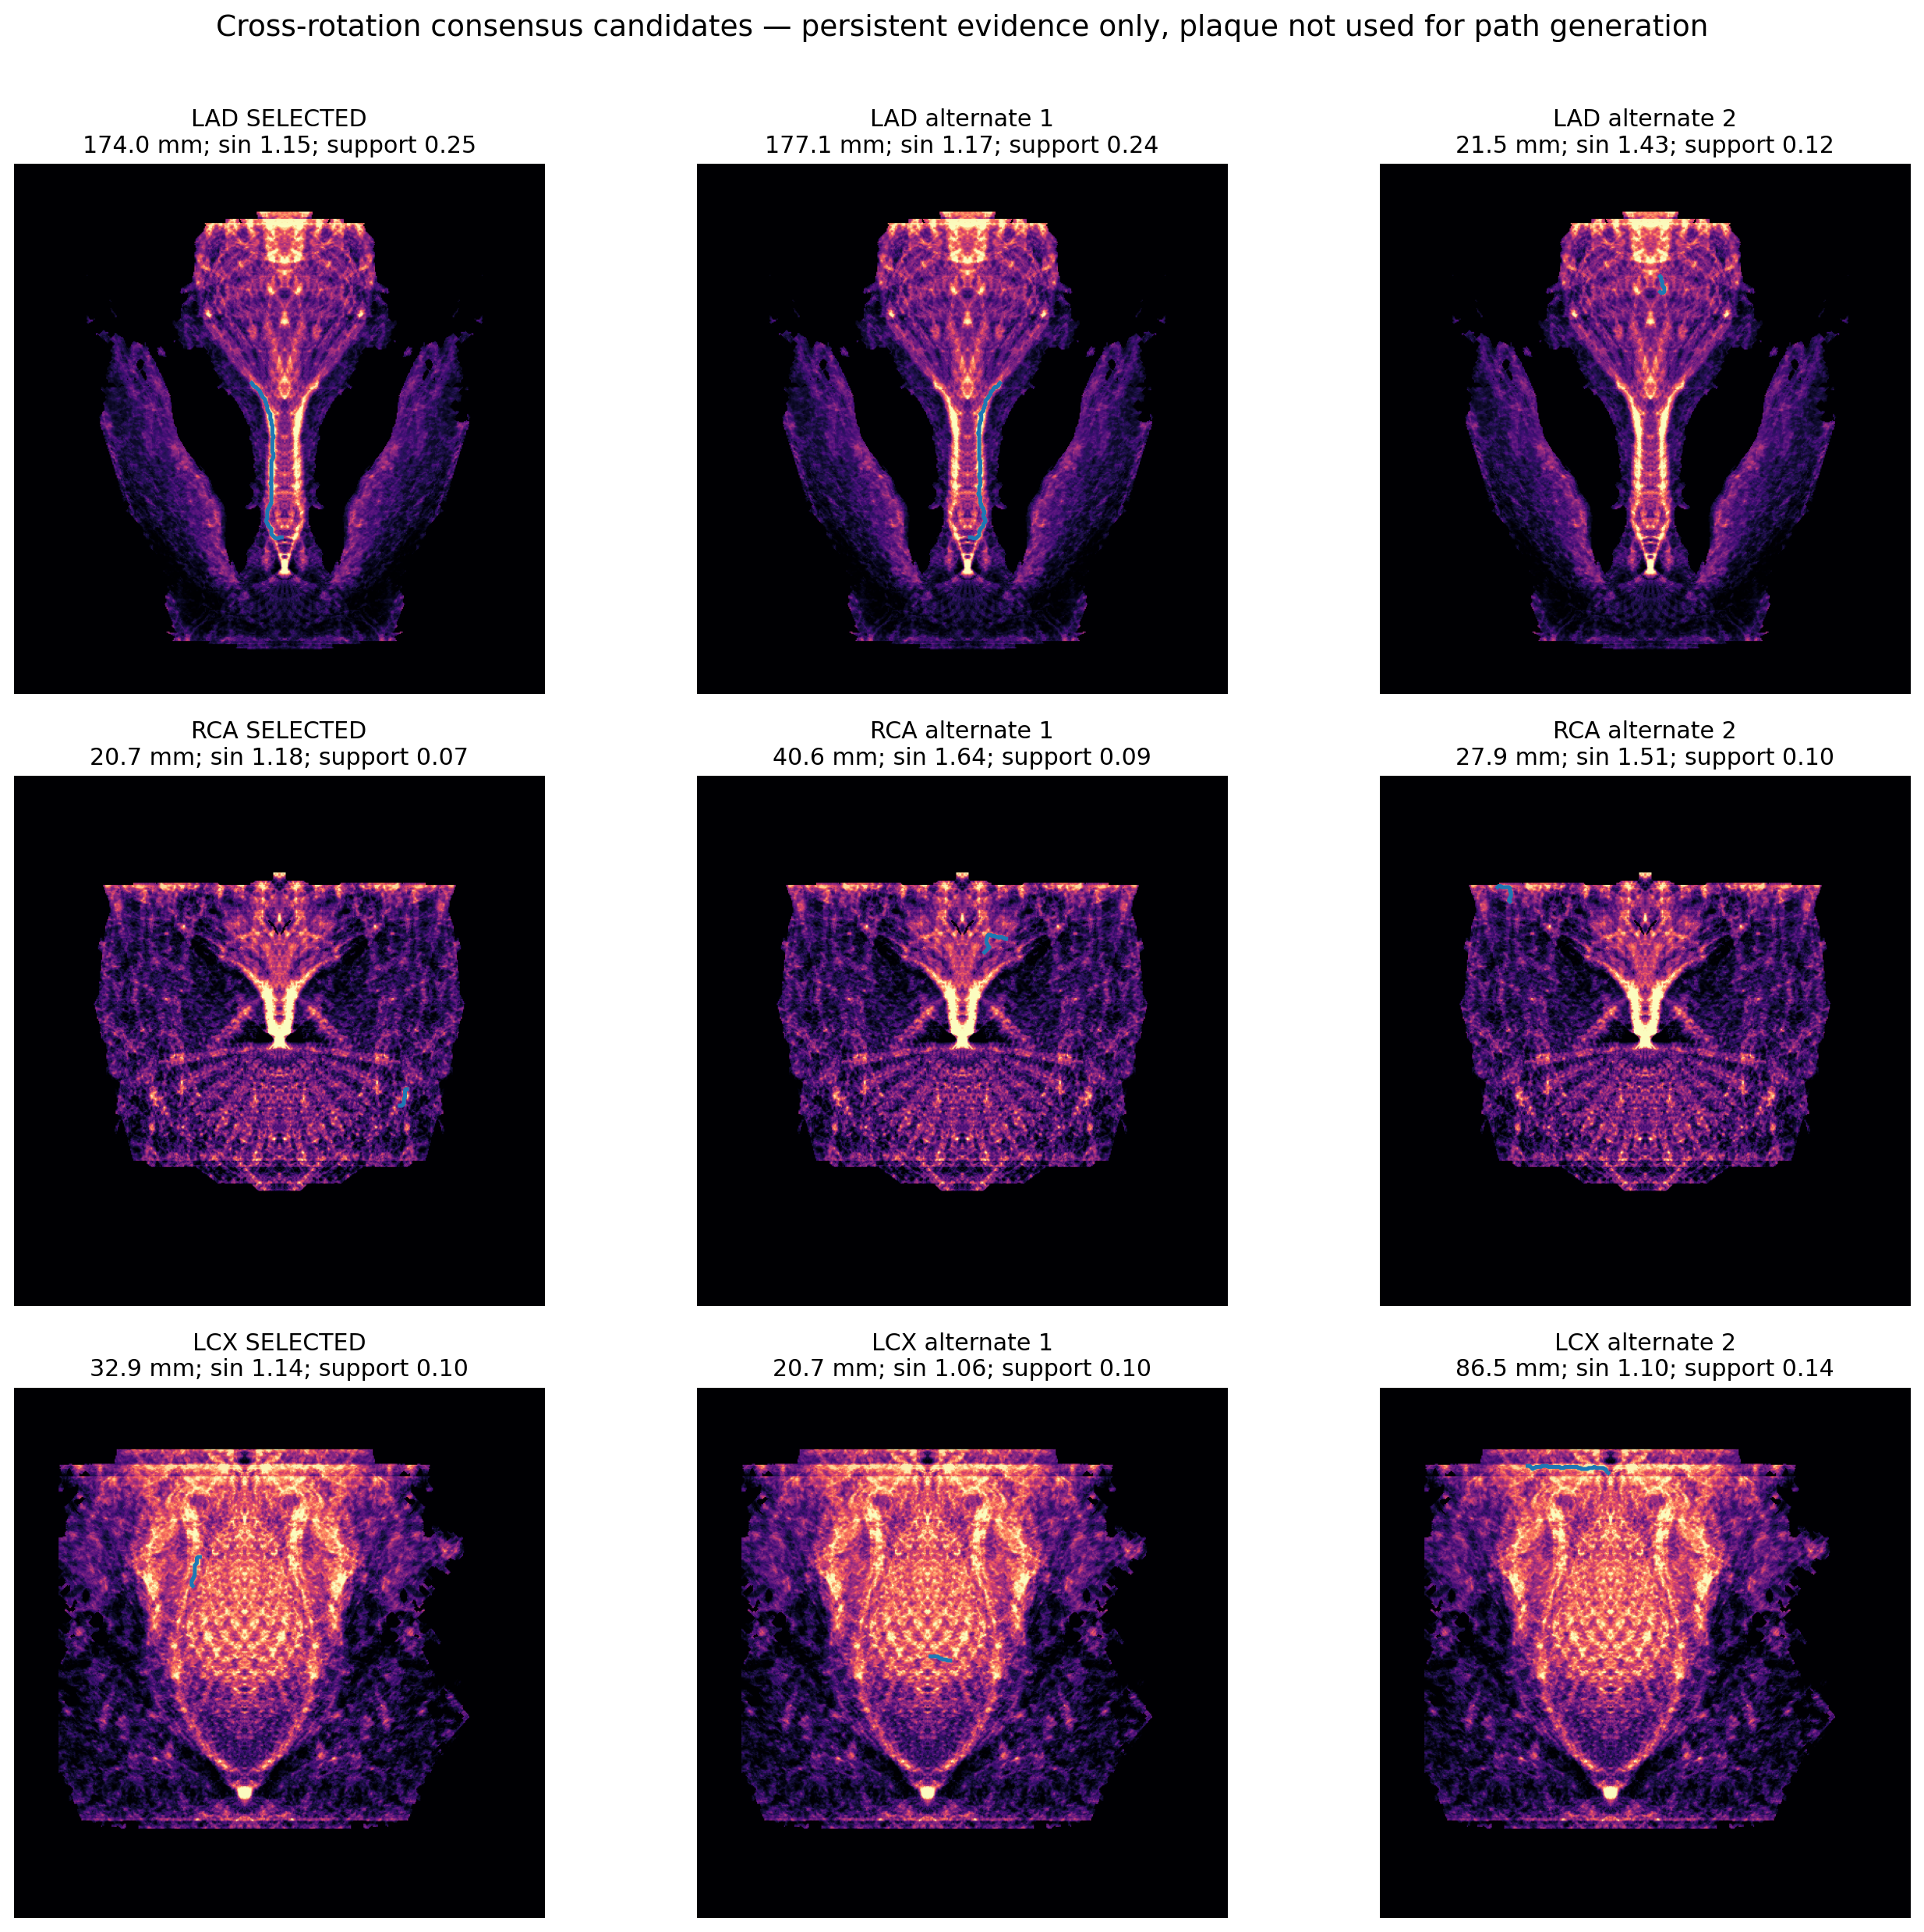

In [9]:
candidate_png = wf.plot_candidates()
print('Saved:', candidate_png)
display(Image(filename=str(candidate_png)))


## Step 10 — Create best-rotation and straightened roadmaps

The left column shows the fixed consensus path on its best CPR rotation. Canonical plaque is overlaid only after tracking. The right column straightens the same path.


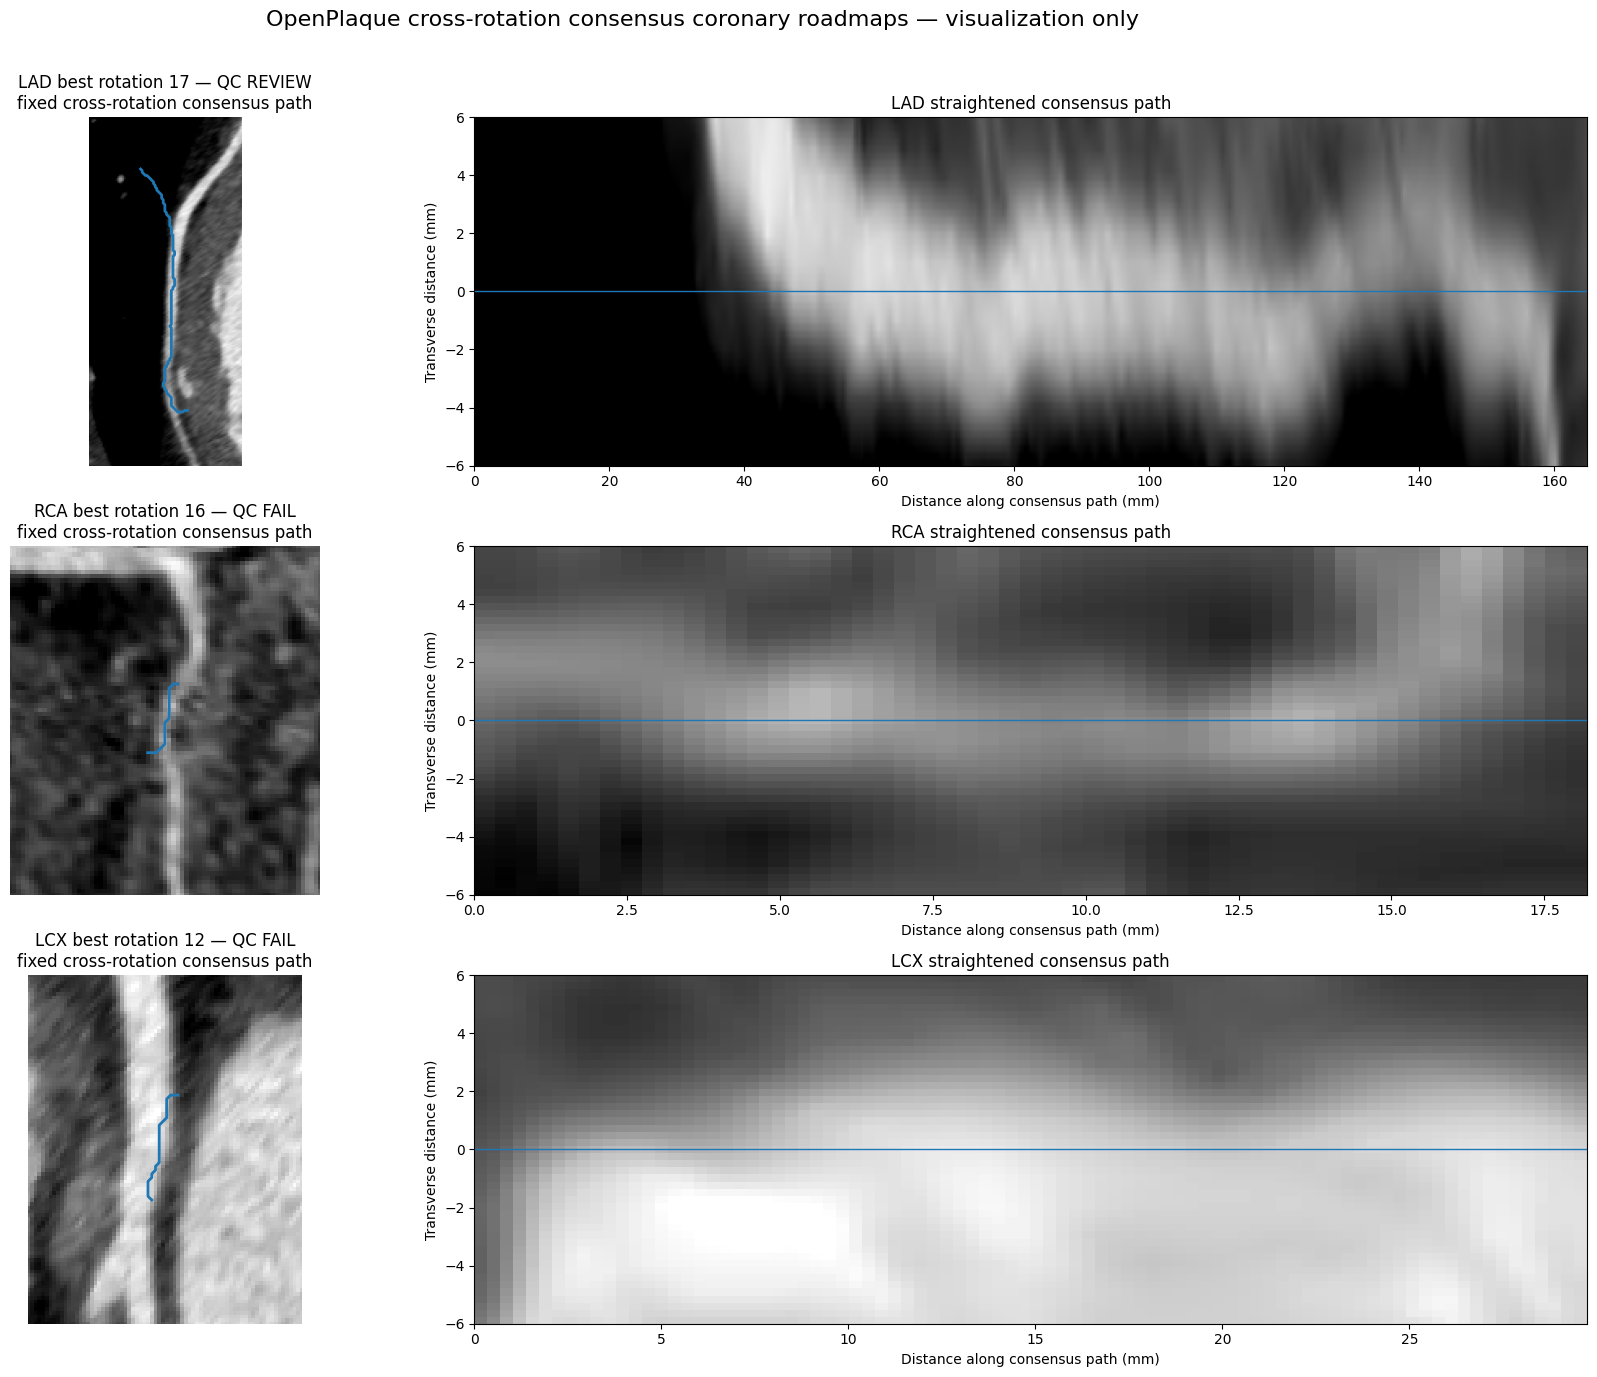

Saved: /content/drive/MyDrive/OpenPlaque/Cross_Rotation_Consensus_Tracking_Report/02_consensus_coronary_roadmaps.png


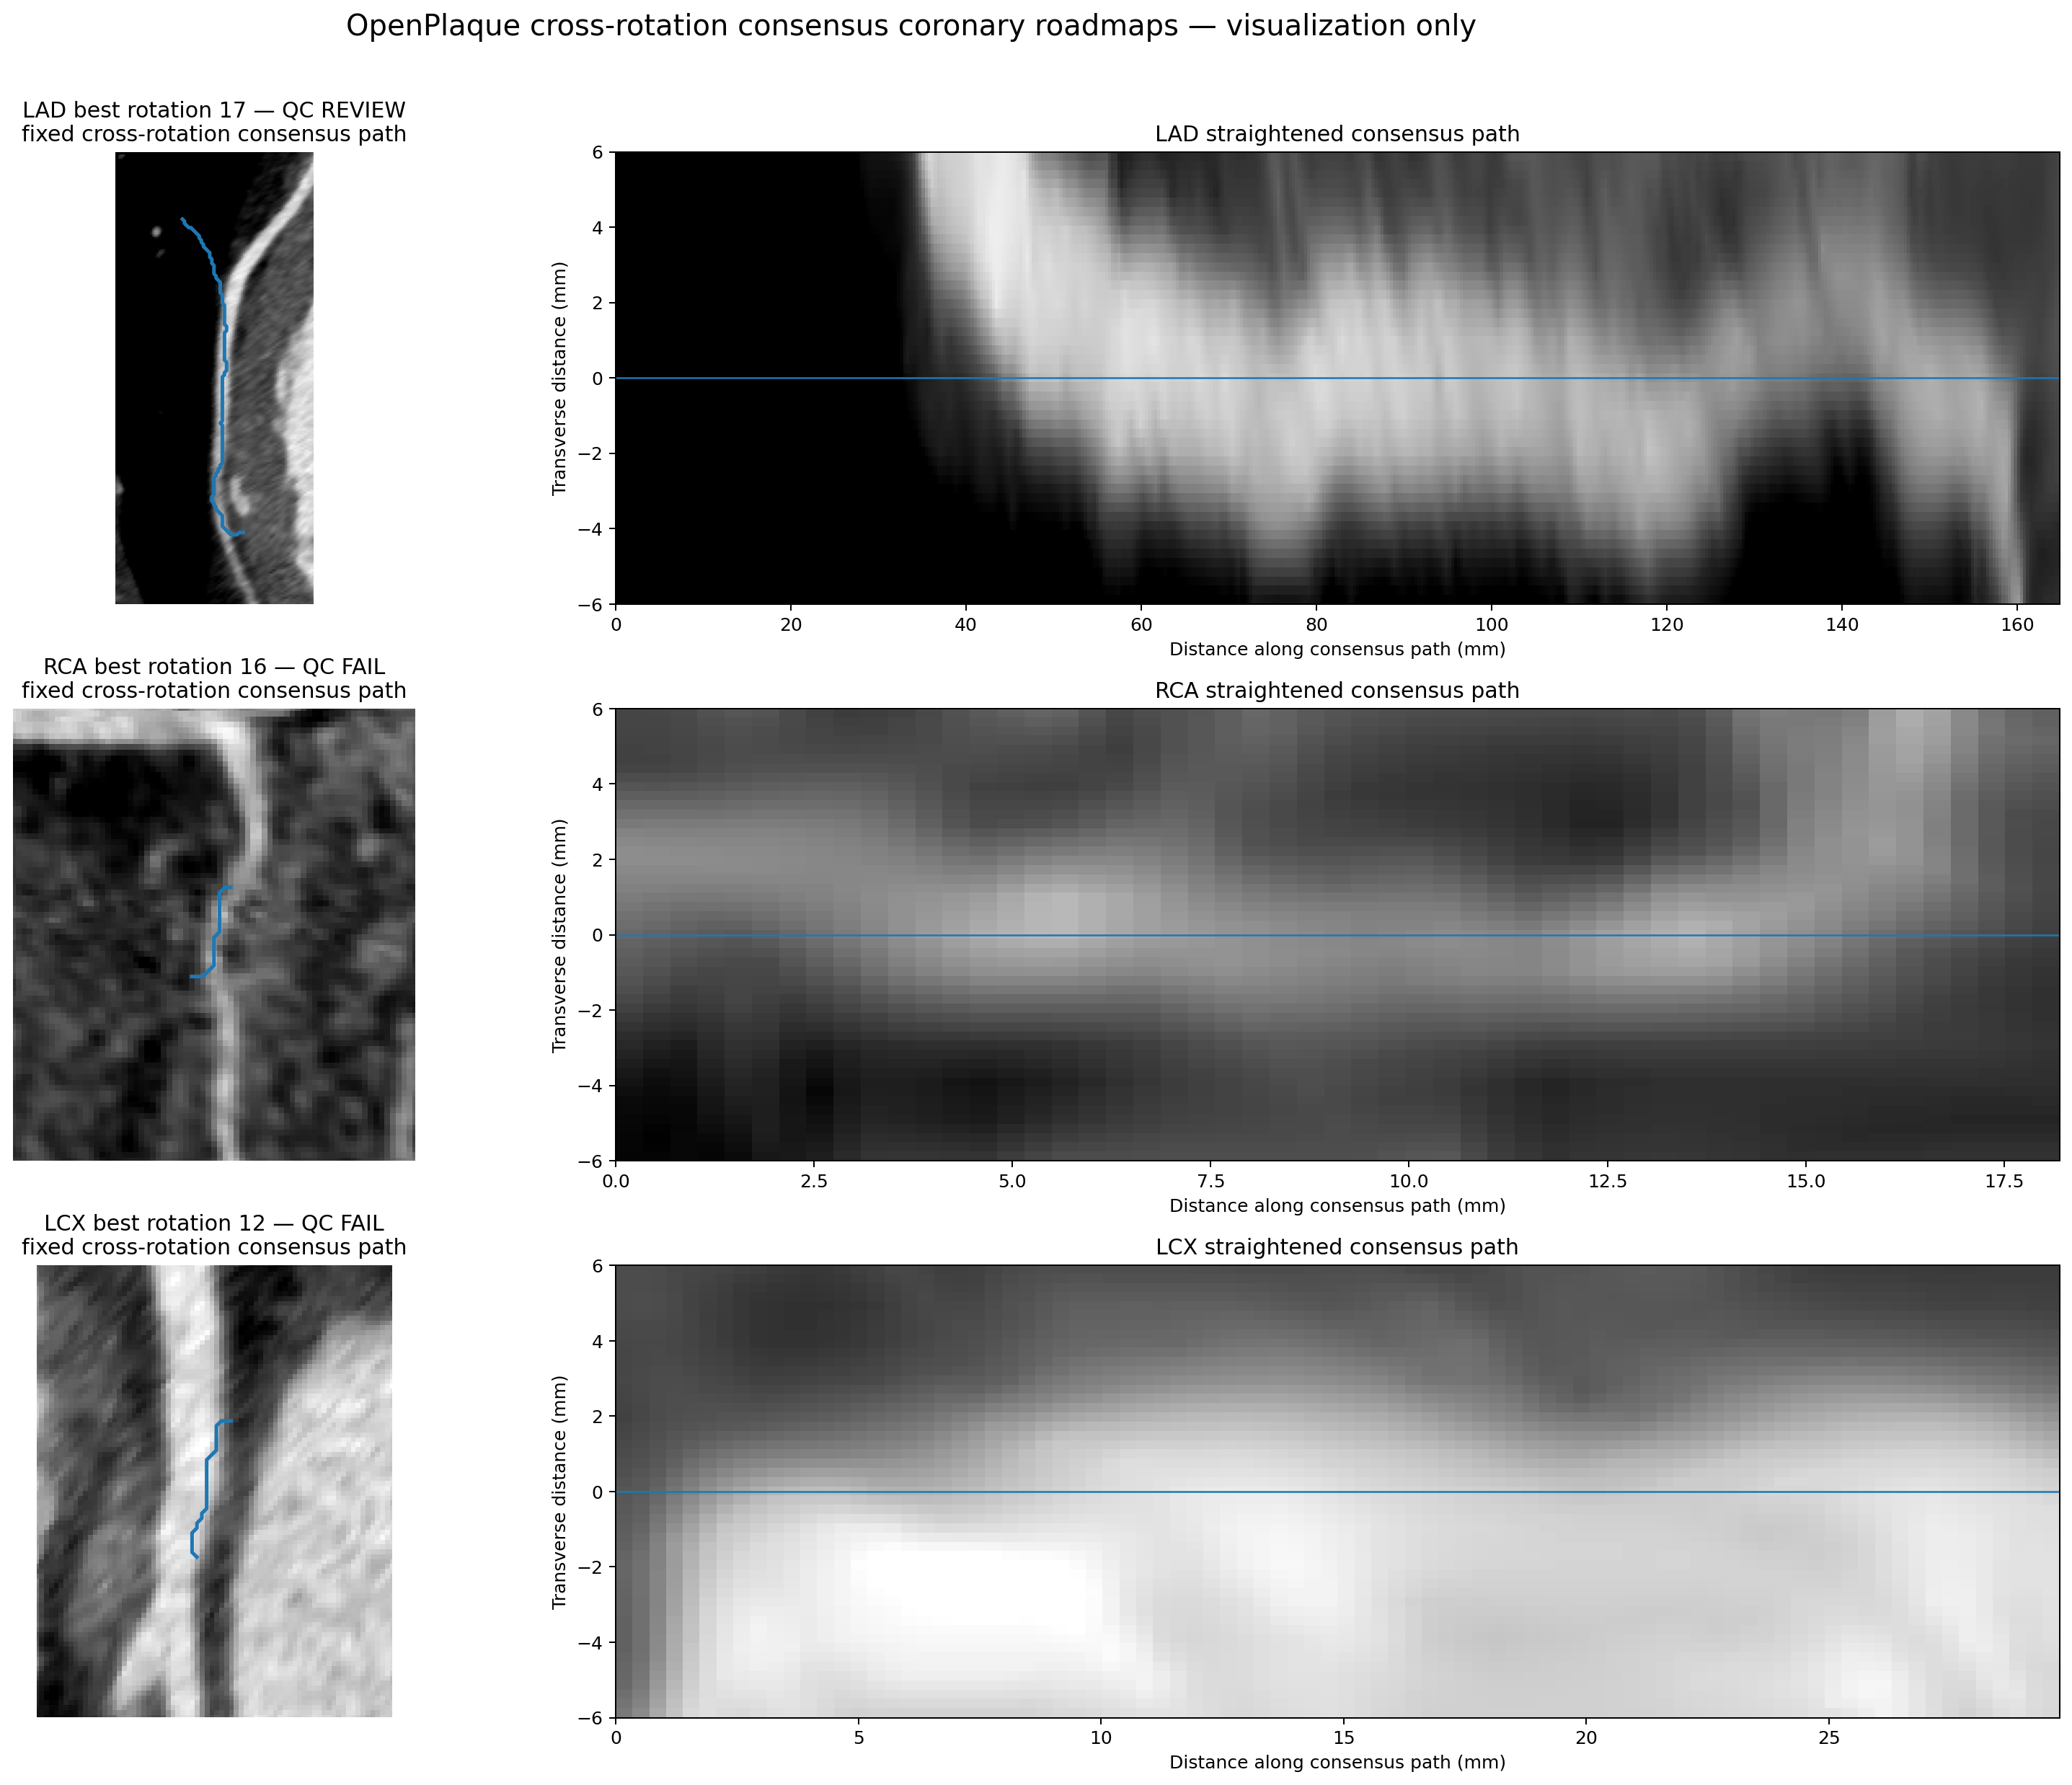

,vessel,start_mm,end_mm,display_plaque_pixels,mean_centerline_hu,tracking_status
0,LAD,0.0,1.0,0,-851.800554,REVIEW
1,LAD,1.0,2.0,0,-878.779534,REVIEW
2,LAD,2.0,3.0,0,-897.746103,REVIEW
3,LAD,3.0,4.0,0,-877.634105,REVIEW
4,LAD,4.0,5.0,0,-892.303230,REVIEW
5,LAD,5.0,6.0,0,-888.308329,REVIEW
6,LAD,6.0,7.0,0,-875.186255,REVIEW
7,LAD,7.0,8.0,0,-897.073298,REVIEW
8,LAD,8.0,9.0,0,-899.360109,REVIEW
9,LAD,9.0,10.0,0,-748.161237,REVIEW


In [10]:
roadmap_png = wf.plot_roadmaps()
print('Saved:', roadmap_png)
display(Image(filename=str(roadmap_png)))
if wf.along_df is not None:
    display(wf.along_df.head(40))


## Step 11 — RCA OpenPlaque PCAT Attenuation figures

The default reuses the validated PCAT visualization. Set `REUSE_PCAT_FIGURES=False` to regenerate it from the frozen RCA centerline/radius/aorta inputs.


{'cross_sections': PosixPath('/content/drive/MyDrive/OpenPlaque/Cross_Rotation_Consensus_Tracking_Report/03_rca_pcat_cross_sections.png'), 'ribbon': PosixPath('/content/drive/MyDrive/OpenPlaque/Cross_Rotation_Consensus_Tracking_Report/04_rca_longitudinal_pcat_ribbon.png')}


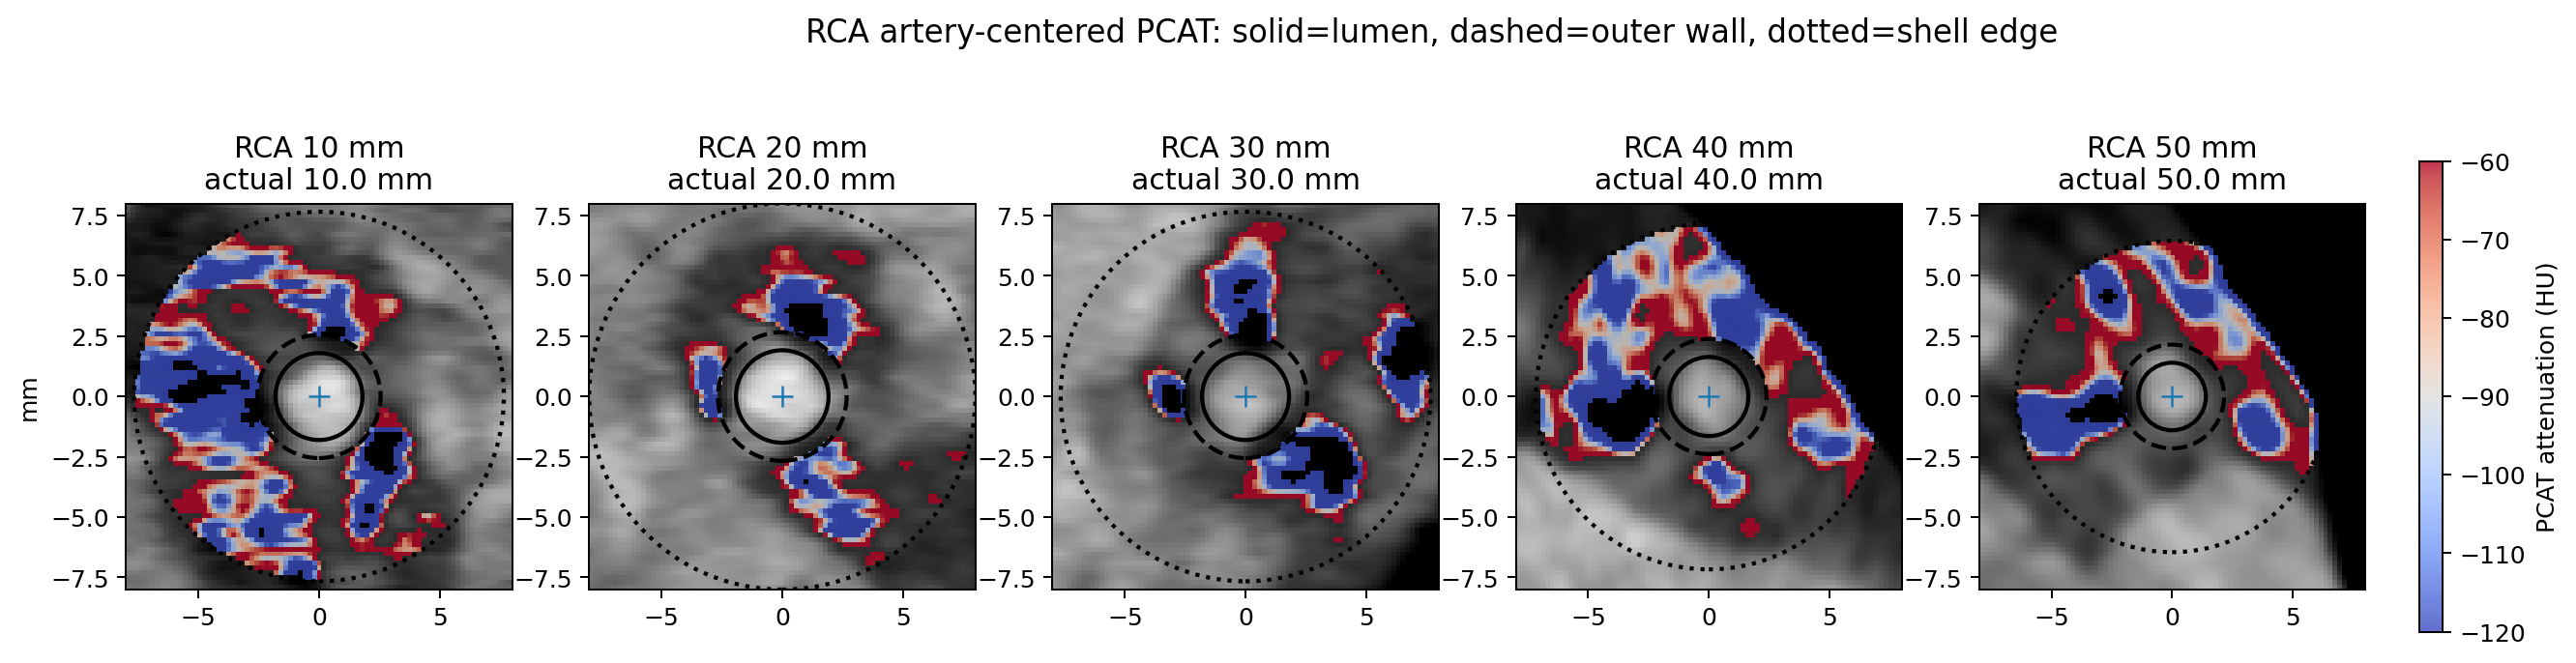

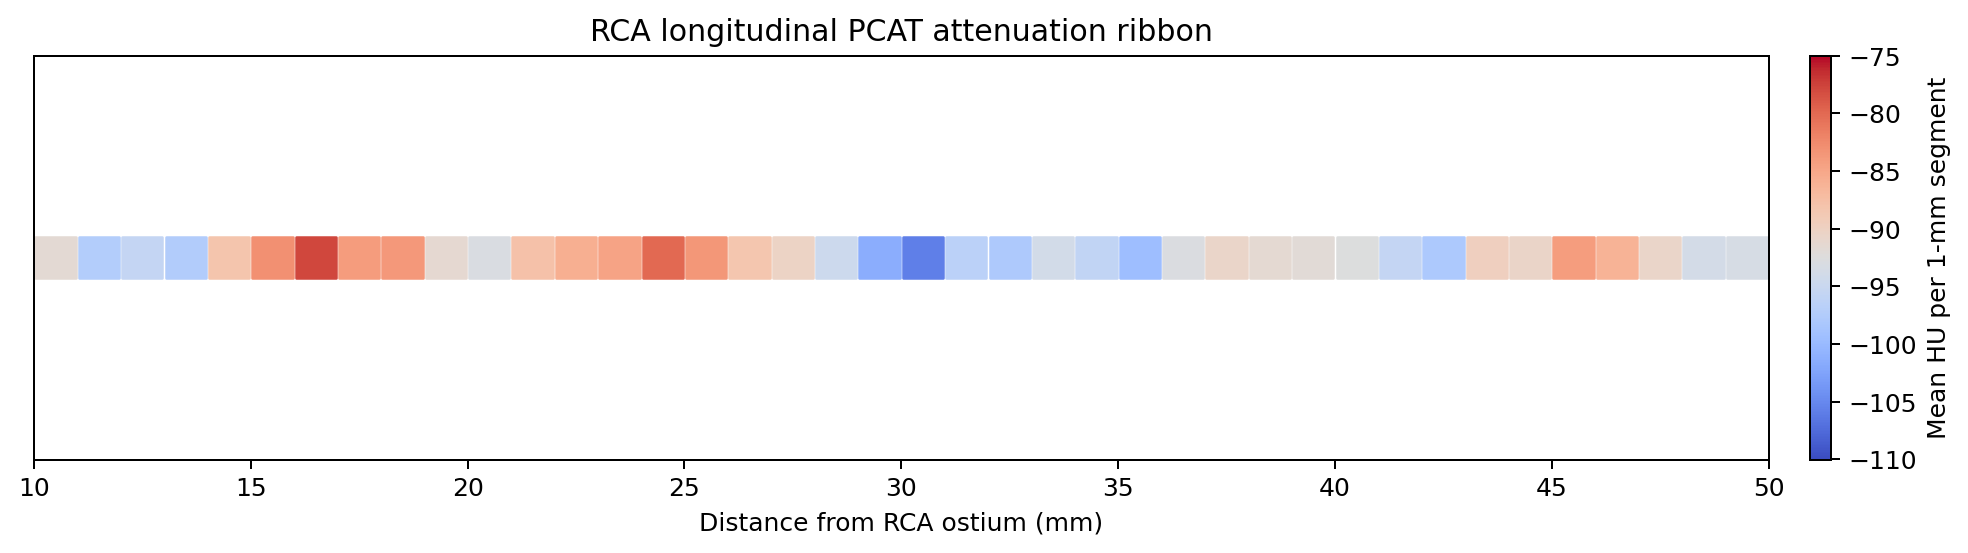

In [11]:
pcat_files = wf.pcat_figures()
print(pcat_files)
display(Image(filename=str(pcat_files['cross_sections'])))
display(Image(filename=str(pcat_files['ribbon'])))


## Step 12 — Build the summary dashboard

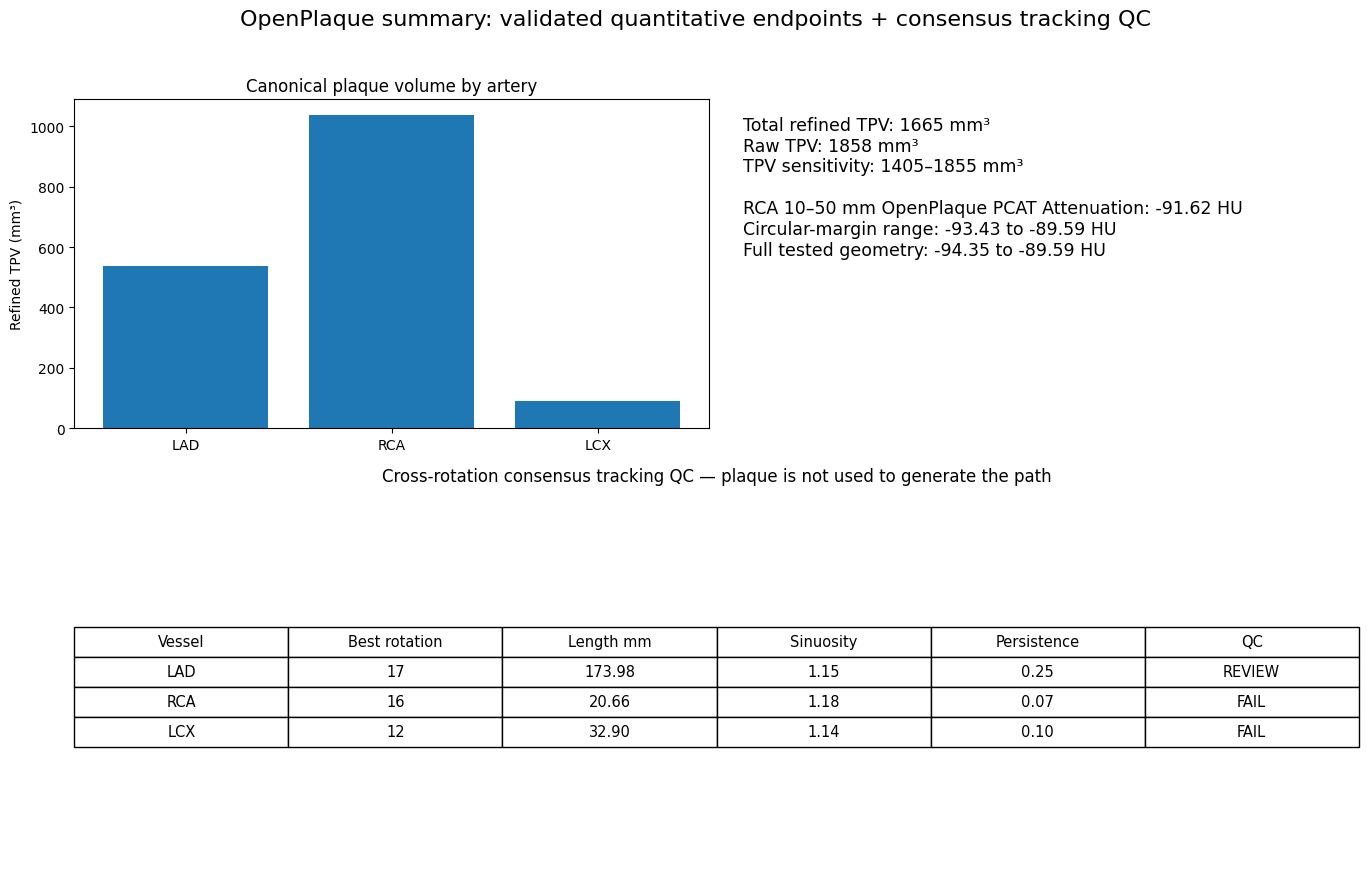

Saved: /content/drive/MyDrive/OpenPlaque/Cross_Rotation_Consensus_Tracking_Report/05_summary_dashboard.png


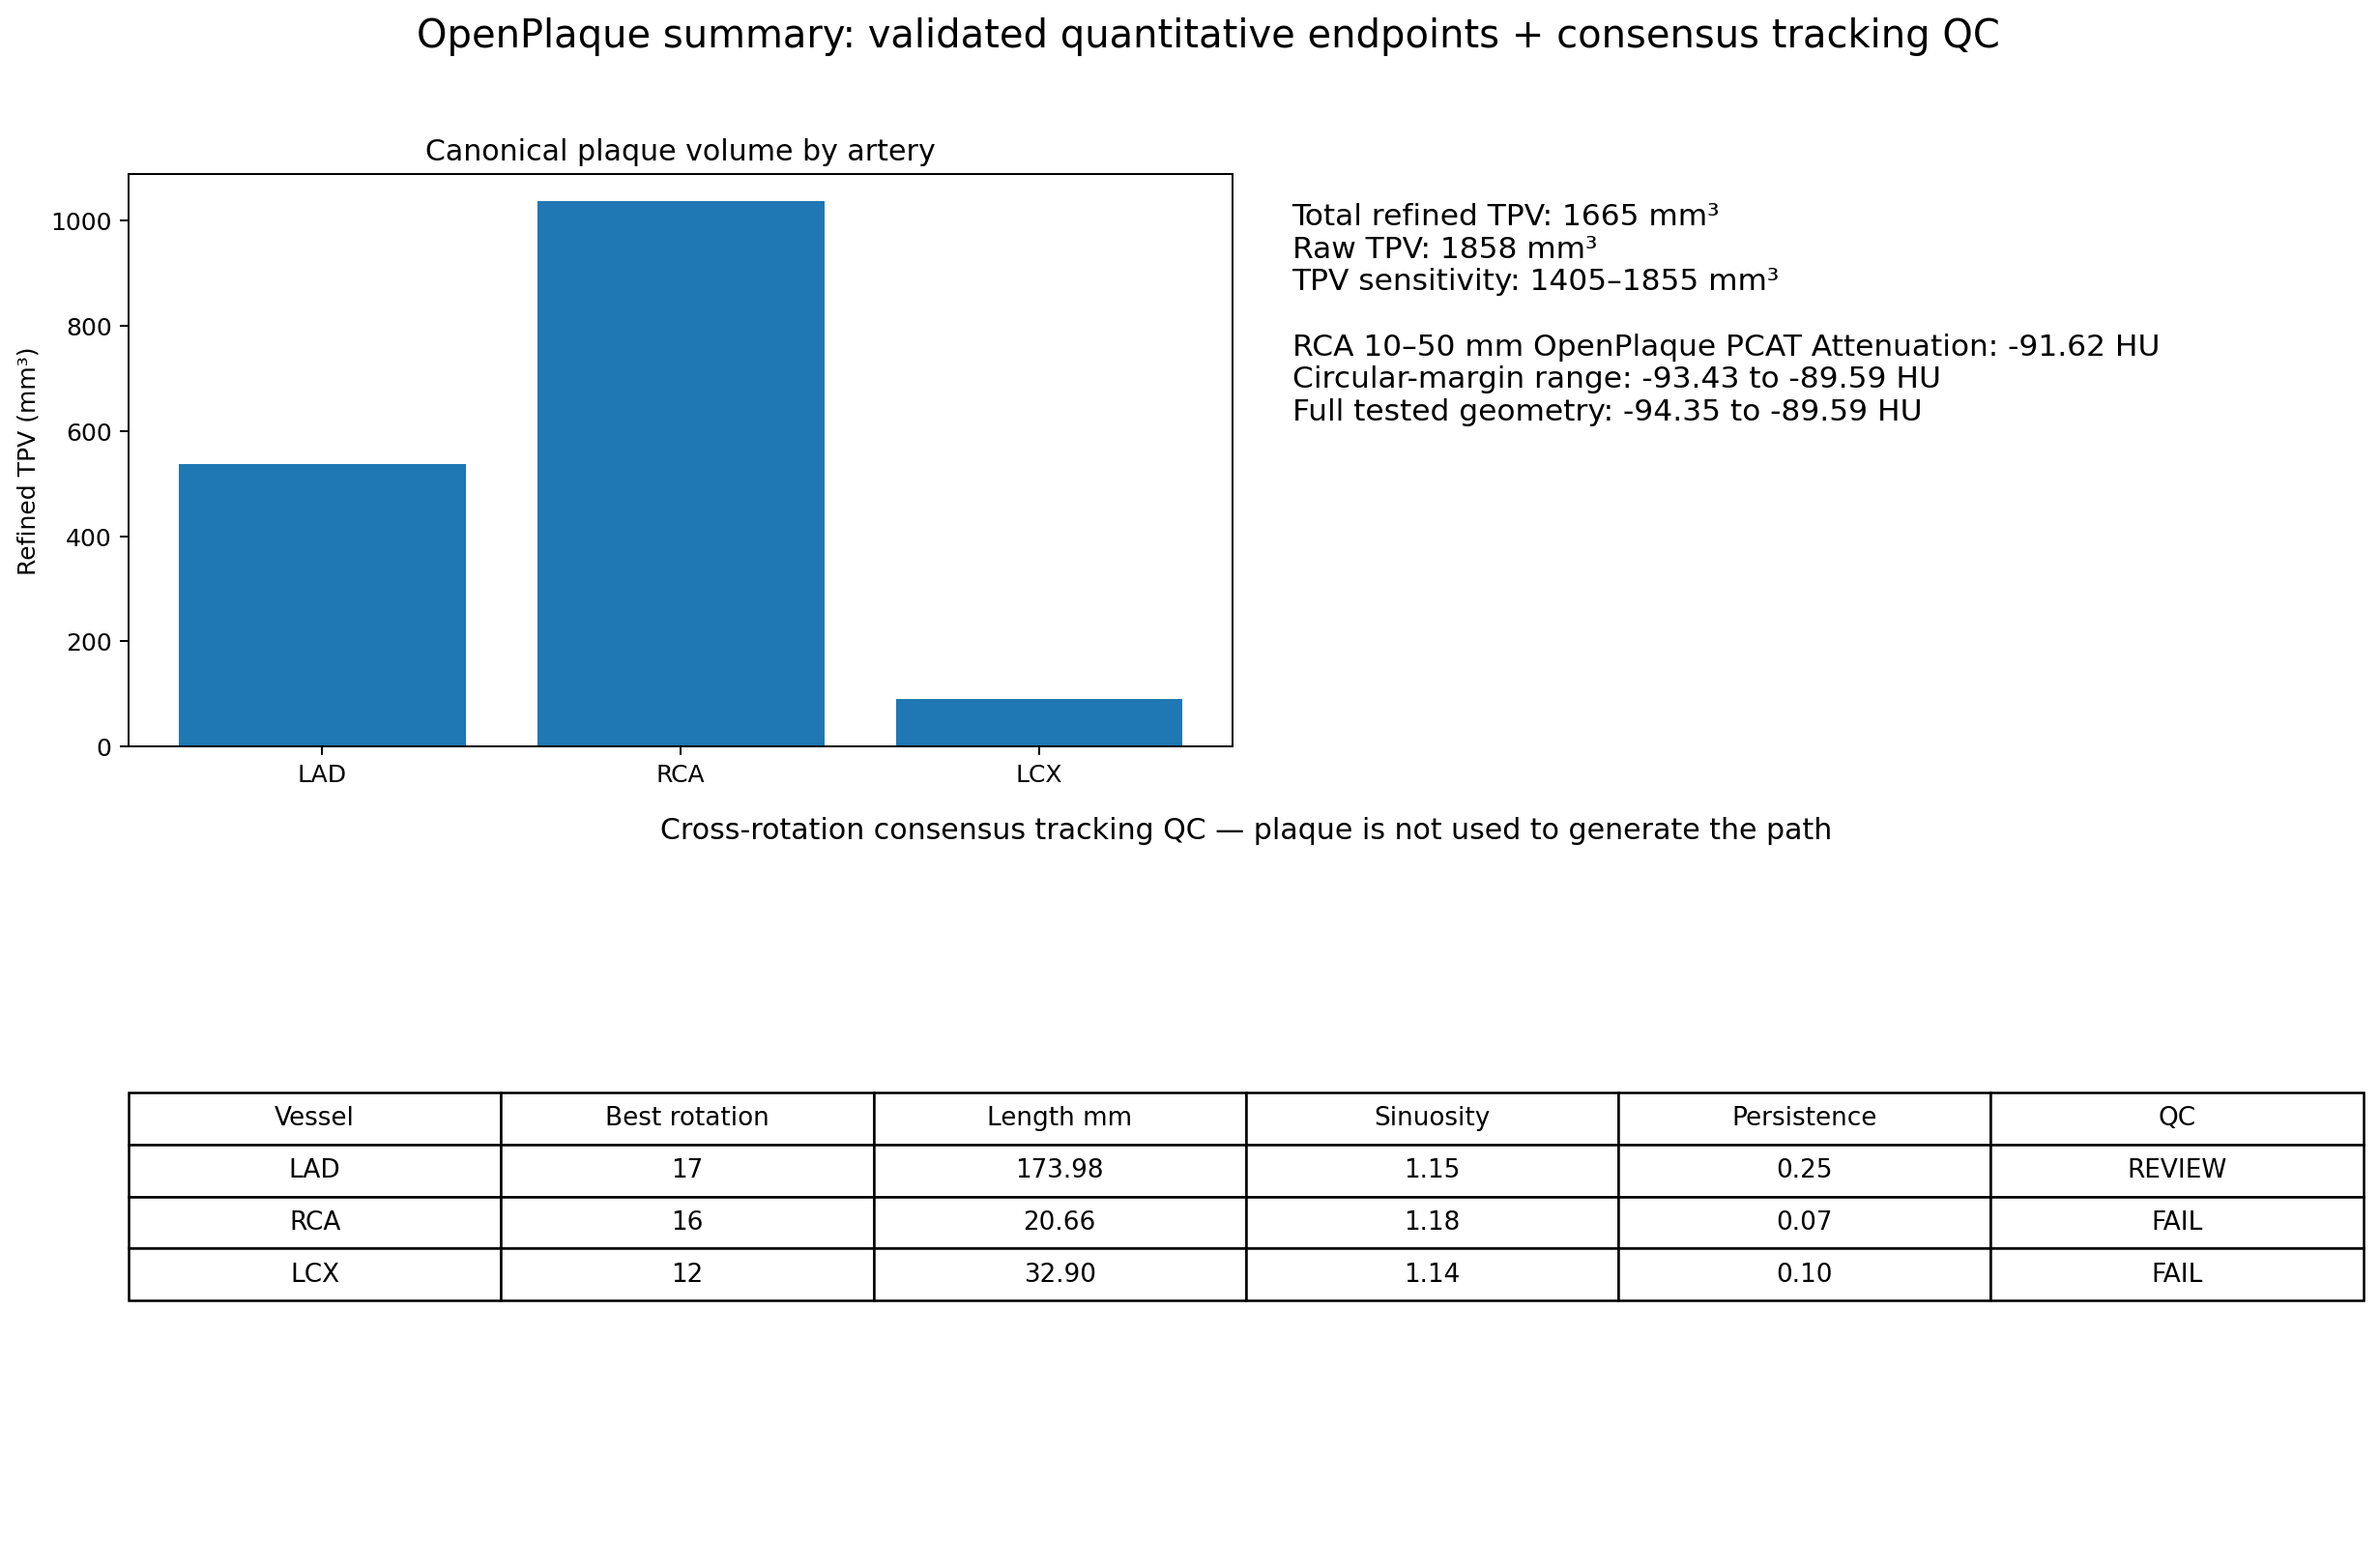

In [12]:
dashboard = wf.plot_dashboard()
print('Saved:', dashboard)
display(Image(filename=str(dashboard)))


## Step 13 — Package the report-back ZIP

The ZIP includes `cache_provenance.csv` as well as all QC tables and figures.


In [13]:
zip_path = wf.package_report()
print('Report ZIP:', zip_path)
print('Drive search: https://drive.google.com/drive/u/0/search?q=OPENPLAQUE_CROSS_ROTATION_CONSENSUS_REPORT_BACK.zip')
print('\nCache provenance:')
display(pd.read_csv(wf.out / 'cache_provenance.csv'))


Report ZIP: /content/drive/MyDrive/OpenPlaque/Cross_Rotation_Consensus_Tracking_Report/OPENPLAQUE_CROSS_ROTATION_CONSENSUS_REPORT_BACK.zip
Drive search: https://drive.google.com/drive/u/0/search?q=OPENPLAQUE_CROSS_ROTATION_CONSENSUS_REPORT_BACK.zip

Cache provenance:


,component,reuse_requested,action,path,note
0,series_selection,True,recomputed_and_cached,/content/drive/MyDrive/OpenPlaque/Cache/Cross_...,NaN
1,plaque_masks,True,reused_or_filled_missing,/content/drive/MyDrive/OpenPlaque/Cache/Cross_...,NaN
2,consensus_evidence,True,reused,/content/drive/MyDrive/OpenPlaque/Cache/Cross_...,NaN
3,tracking,True,recomputed_and_cached,/content/drive/MyDrive/OpenPlaque/Cache/Cross_...,NaN
4,candidate_figure,True,recomputed_and_cached,/content/drive/MyDrive/OpenPlaque/Cross_Rotati...,NaN
5,roadmaps,True,recomputed_and_cached,/content/drive/MyDrive/OpenPlaque/Cross_Rotati...,NaN
6,pcat_figures,True,imported_validated_cache,/content/drive/MyDrive/OpenPlaque/Cache/Cross_...,NaN
7,dashboard,True,recomputed_and_cached,/content/drive/MyDrive/OpenPlaque/Cross_Rotati...,NaN
8,report_package,True,recomputed_and_cached,/content/drive/MyDrive/OpenPlaque/Cross_Rotati...,NaN
